## <strong> 3. NumPy 고급 기능 </strong>
+ 브로드캐스팅 (broadcasting)
+ 마스킹 (masking)
+ 팬시 인덱싱 (fancy indexing)

In [4]:
import numpy as np

### <strong> 브로드캐스팅 연산 </strong>
+ ```np.ones()```: 1로 이루어진 NumPy 배열 생성

In [6]:
# 1D + 스칼라
a = np.array([0, 1, 2])
a + 5

array([5, 6, 7])

In [8]:
# 1D + 2D 배열
a = np.ones((3, 3))     # [+] 1로 이루어진 (3, 3)의 배열 생성
print(a, '\n')

b = np.array([0, 1, 2])  # [+] [0, 1, 2]로 이루어진 정수 배열 생성
print(b, '\n')

print(a+b)

[[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]] 

[0 1 2] 

[[1. 2. 3.]
 [1. 2. 3.]
 [1. 2. 3.]]


In [10]:
# 두 배열 모두 브로드캐스팅이 적용되는 경우
a = np.arange(3)
a = a[:, np.newaxis]   # [+] 차원 추가: (3,) -> (3, 1)
print(a, '\n')

b = np.arange(3)
print(b, '\n')

print(a + b)

[[0]
 [1]
 [2]] 

[0 1 2] 

[[0 1 2]
 [1 2 3]
 [2 3 4]]


### <strong> 브로드캐스팅 규칙 </strong>

In [12]:
# 예제: 1D + 2D
a = np.ones((2, 3))
b = np.arange(3)

a+b

array([[1., 2., 3.],
       [1., 2., 3.]])

In [14]:
# 예제: 두 배열 모두 브로드캐스팅이 적용되는 경우
a = np.arange(3)
a = a.reshape((3, 1))
b = np.arange(3)

a+b

array([[0, 1, 2],
       [1, 2, 3],
       [2, 3, 4]])

In [26]:
# 예제: 브로드캐스팅이 불가능한 경우
a = np.ones((3, 2))
print(a, '\n')

b = np.arange(3)
print(b, '\n')

print(a + b)

[[1. 1.]
 [1. 1.]
 [1. 1.]] 

[0 1 2] 



ValueError: operands could not be broadcast together with shapes (3,2) (3,) 

### <strong> 비교 연산, 마스크, 불리언 연산 </strong>

In [28]:
# 배열의 비교 연산(마스킹)
x = np.array([1, 2, 3, 4, 5])

print(x < 3)
print(x >= 3)
print(x != 3)
print(x == 3)

[ True  True False False False]
[False False  True  True  True]
[ True  True False  True  True]
[False False  True False False]


#### **예제: 시애틀 2014년 강수량**

In [30]:
import pandas as pd  # 데이터 조작을 위한 라이브러리

df = pd.read_csv('data/seattle2014.csv')
prcp = df['PRCP'].values   # PRCP: Precipitation (강수량)
prcp = prcp / 254.0  # 인치(inch) 단위로 변환
prcp[:10]

array([0.        , 0.16141732, 0.05905512, 0.        , 0.        ,
       0.01181102, 0.48031496, 0.38188976, 0.22834646, 0.16929134])

In [32]:
prcp > 0

array([False,  True,  True, False, False,  True,  True,  True,  True,
        True,  True,  True, False, False, False, False, False, False,
       False, False, False,  True, False, False, False, False, False,
        True,  True, False,  True,  True, False, False, False, False,
       False, False,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True, False, False, False,  True,  True,  True,  True,
        True,  True, False,  True,  True,  True, False, False,  True,
        True,  True,  True,  True, False,  True, False, False, False,
       False, False,  True,  True,  True,  True,  True, False, False,
       False, False,  True, False,  True, False, False,  True, False,
       False, False, False, False, False,  True,  True,  True, False,
        True, False,  True,  True,  True,  True, False,  True,  True,
       False, False, False, False, False,  True,  True,  True, False,
       False,  True,

In [34]:
# [+] 비가 온 날은 며칠일까?
np.sum([prcp > 0])

150

In [42]:
# [+] 비가 온 날의 평균 강수량은?
np.mean(prcp[prcp > 0])

0.32356955380577423

In [46]:
# [+] 0.5인치 이상 비가 온 날은 며칠?
np.sum([prcp >= 0.5])

39

#### **시각화 라이브러리 (seaborn) 설치**

In [48]:
!pip install seaborn


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [56]:
# 시각화 설정 코드
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn; seaborn.set() 
%config InlineBackend.figure_format = 'svg'

In [66]:
# 강수량 히스토그램 시각화
plt.hist(prcp, 40);

In [60]:
# 다차원 배열의 비교 연산
np.random.seed(0)
x = np.random.randint(10, size=(3, 4))
print(x, '\n')

print(x < 6)

[[5 0 3 3]
 [7 9 3 5]
 [2 4 7 6]] 

[[ True  True  True  True]
 [False False  True  True]
 [ True  True False False]]


In [62]:
# Boolean 배열 연산
print(np.count_nonzero(x < 6))  # [+] 6보다 작은가? np.count_nonzero()
print(np.sum(x < 6))            # [+] 6보다 작은가? np.sum()
print(np.any(x > 8))            # [+] 8보다 큰 값이 있는가?
print(np.all(x > 1))            # [+] 모든 값이 1보다 큰가? 

8
8
True
False


In [64]:
# Boolean 배열을 이용한 데이터 선택
print(x, '\n')
print(x < 5, '\n')

print(x[x < 5])

[[5 0 3 3]
 [7 9 3 5]
 [2 4 7 6]] 

[[False  True  True  True]
 [False False  True False]
 [ True  True False False]] 

[0 3 3 3 2 4]


### <strong> 팬시 인덱싱(fancy indexing) </strong>

In [68]:
# 난수 배열 생성
np.random.seed(1)
x = np.random.randint(100, size=10)
x

array([37, 12, 72,  9, 75,  5, 79, 64, 16,  1])

In [70]:
# 기본 문법: 2, 4, 6번 원소 선택하기
a = x[2]
b = x[4]
c = x[6]

print([a, b, c])

[72, 75, 79]


In [74]:
# 팬시 인덱싱: 2, 4, 6번 원소 선택하기
ind = np.random.randint(100, size=10)  # [+] 인덱스 배열 생성
ind = [2, 4, 6] # [+] 인덱스 배열을 이용한 값 선택
print(x[ind])

[72 75 79]


In [76]:
# 팬시 인덱싱: 다차원 배열
np.random.seed(2)
x = np.random.randint(10, size=(3, 5))
print(x, '\n')

row = [0, 1, 2]
col = [2, 1, 4]

print(x[row, col])

[[8 8 6 2 8]
 [7 2 1 5 4]
 [4 5 7 3 6]] 

[6 2 6]


In [78]:
# 팬시 인덱싱: 다차원 배열 + 브로드캐스팅
row = np.array([0, 1, 2])
col = np.array([2, 1, 4])

x[row[:, np.newaxis], col]

array([[6, 8, 8],
       [1, 2, 4],
       [7, 5, 6]])

In [80]:
# 결합 인덱싱
x = np.arange(1, 13).reshape(3, 4)
print(x, '\n')

ind = [2, 0, 1]

print(x[2, ind], '\n')
print(x[1:, [2, 0, 1]])

[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]] 

[11  9 10] 

[[ 7  5  6]
 [11  9 10]]


#### **예제: 팬시 인덱싱을 이용한 임의의 점 집합 선택하기**
+ ```np.random.seed()```: 난수 생성을 위한 초기상태(seed)를 관리 (전역적 상태)
+ ```np.random.RandomState()```: seed를 별도 객체에서 관리 (지역적 상태) ${\rightarrow}$ 독립적인 난수 생성기를 여러 개 생성 가능

In [16]:

mean = [0, 0]     # 평균
cov = [[1, 2],    # 공분산
      [2, 5]]

rand = np.random.RandomState(1)  # RandomState: 시드를 별도 객체에서 관리
x = rand.multivariate_normal(mean, cov, 100)  # 정규분포 다변량 데이터 생성
print(x[:10])
print(x.shape)

[[-1.26659039e+00 -3.71998007e+00]
 [ 8.98574387e-01  1.00797760e+00]
 [ 8.12283322e-02 -2.29506499e+00]
 [-1.32069461e+00 -4.01236325e+00]
 [-1.99323780e-01 -7.51126722e-01]
 [-5.62429879e-01 -3.58770608e+00]
 [ 4.44845894e-01  6.58255553e-01]
 [-6.26556217e-01 -2.70315425e+00]
 [ 4.95244764e-01  2.45439522e-01]
 [-2.62034143e-01 -1.77174030e-03]]
(100, 2)


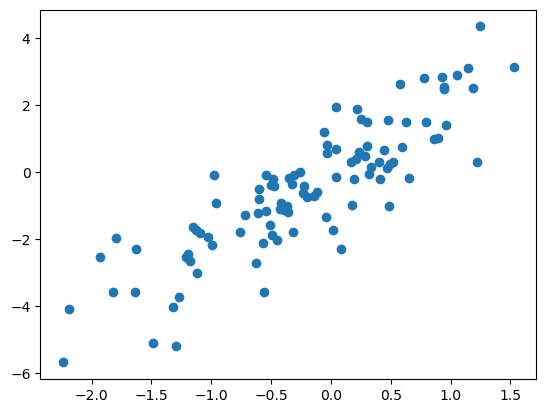

In [18]:
import matplotlib.pyplot as plt
# 산포도 출력: scatter(x, y)
plt.scatter(x[:, 0], x[:, 1]);

In [20]:
# 20개의 점을 무작위 추출(random sampling) -> 인덱스 값을 리턴
ind = np.random.choice(x.shape[0], 20, replace=False)
print(ind)

[25  6 76 91 85 65 22 99 23  1 53 82 50 73 24 35 90 41 78 64]


In [22]:
# 선택된 점 집합 출력
selected = x[ind]      # 팬시 인덱싱
print(selected)
print(selected.shape)

[[-0.14252103 -0.7253487 ]
 [ 0.44484589  0.65825555]
 [-1.79666967 -1.97037456]
 [-0.95977827 -0.91733211]
 [ 0.25268899  1.58580757]
 [ 0.39825898  0.30780326]
 [ 0.19682744 -0.21429565]
 [-1.14891234 -1.64322377]
 [-0.98011575 -0.09290897]
 [ 0.89857439  1.0079776 ]
 [-0.31921953 -1.80294221]
 [-0.3906596  -1.13223305]
 [-0.05550588  1.19139454]
 [-0.30854123 -0.07555445]
 [-0.3472058  -0.17017312]
 [ 1.52723792  3.14104857]
 [ 1.05570147  2.88807041]
 [-0.32928022 -0.35111607]
 [ 0.17161857  0.28546056]
 [ 0.77759124  2.81174955]]
(20, 2)


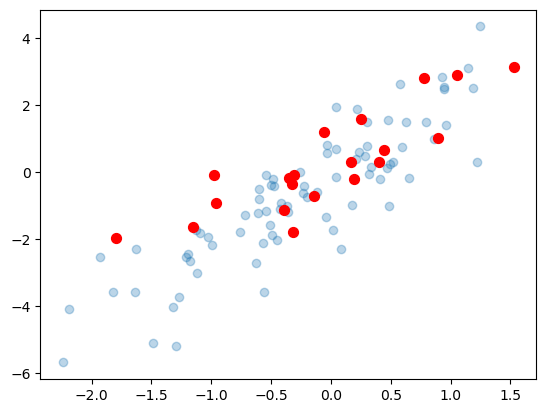

In [24]:
# 선택된 점 집합 시각화
plt.scatter(x[:, 0], x[:, 1], alpha=0.3)    # 원본 점 집합
plt.scatter(selected[:, 0], selected[:, 1], # 선택된 점 집합
            facecolor='red', s=50);